In [1]:
# TODO: Install any packages that you might need
# For instance, you will need the smdebug package 
%pip install smdebug
%pip install seaborn
%pip install bokeh

  Using cached smdebug-1.0.34-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
  Using cached pyinstrument-3.4.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pyinstrument_cext-0.2.4-cp311-cp311-linux_x86_64.whl
Using cached smdebug-1.0.34-py2.py3-none-any.whl (280 kB)
Using cached pyinstrument-3.4.2-py2.py3-none-any.whl (83 kB)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.
  Using cached bokeh-3.6.2-py3-none-any.whl.metadata (12 kB)
  Using cached xyzservices-2024.9.0-py3-none-any.whl.metadata (4.

## Notes/References:
https://pytorch.org/hub/pytorch_vision_resnet/
<br>All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

In [2]:
# TODO: Import any packages that you might need
# For instance you will need Boto3 and Sagemaker
import sagemaker
import boto3
import IPython

from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)
from sagemaker.pytorch import PyTorch

import numpy as np
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import Image

import os
import random
import math

from sagemaker.debugger import Rule, ProfilerRule, rule_configs
from sagemaker.debugger import DebuggerHookConfig, ProfilerConfig, FrameworkProfile, CollectionConfig
from smdebug.profiler.analysis.notebook_utils.training_job import TrainingJob
from smdebug.profiler.analysis.notebook_utils.timeline_charts import TimelineCharts

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
[2025-01-14 19:30:06.043 default:563 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None


## Dataset
TODO: Explain what dataset you are using for this project. Maybe even give a small overview of the classes, class distributions etc that can help anyone not familiar with the dataset get a better understand of it.

In [3]:
#TODO: Fetch and upload the data to AWS S3

# Command to download and unzip data
# !wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
!wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip --no-check-certificate

--2024-12-21 22:18:32--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 52.219.221.16, 52.219.120.16, 52.219.220.96, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|52.219.221.16|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip.1’

dogImages.zip.1     100%[===================>]   1.05G  41.0MB/s    in 26s     

2024-12-21 22:18:59 (41.2 MB/s) - ‘dogImages.zip.1’ saved [1132023110/1132023110]



In [4]:
!unzip -o dogImages.zip 


Archive:  dogImages.zip
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00003.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00023.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00036.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00047.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00048.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00058.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00071.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00078.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00116.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00125.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00139.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00141.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00143.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afgha

## Create the label file
Read the image folder and create the manifest/annotation/label file, for model training


In [3]:
dir_path = "dogImages"
d = {}
for dirpath, dirnames, filenames in os.walk(dir_path):
    # print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
    # print("{}: {} : {}".format(dirpath, dirnames, filenames))
    if  filenames:
        # print("{}:   {}".format(dirpath,   filenames))
        d[dirpath] = filenames

# pd.DataFrame.from_dict(d, orient='index')
df=pd.DataFrame(pd.Series(d).reset_index()).rename(columns={0: 'names'}).explode('names')

df.head()

,index,names
0,dogImages/test/001.Affenpinscher,Affenpinscher_00003.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00023.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00036.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00047.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00048.jpg


In [4]:
df[df['index'].str.contains("Airedale_terrier")].to_csv('temp.csv')

In [5]:
train_classes = len(df[df['index'].str.contains('train')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')
test_classes  = len(df[df['index'].str.contains('test')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')
valid_classes = len(df[df['index'].str.contains('valid')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')

print(f"Count of \nTrain Classes: {train_classes}, \nTest Classes: {test_classes}, \nValidation Classes: {valid_classes}")

Count of 
Train Classes: 133, 
Test Classes: 133, 
Validation Classes: 133


### lets inspect some of the training images 

In [6]:
df.head()

,index,names
0,dogImages/test/001.Affenpinscher,Affenpinscher_00003.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00023.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00036.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00047.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00048.jpg


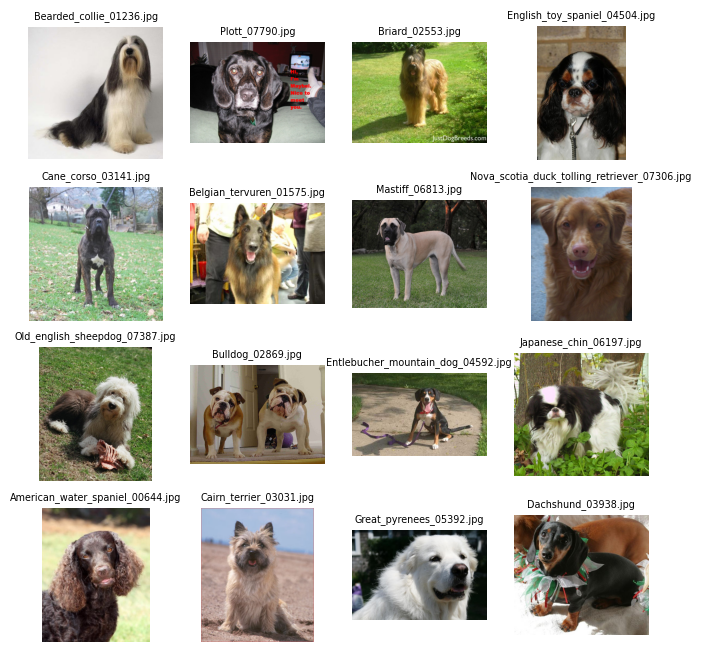

In [7]:
displayImages = 16
rows = cols = int(math.sqrt(displayImages))

df_train = df[df['index'].str.contains('train')]

totalImages = len(df_train)

fig, ax = plt.subplots(rows, cols , figsize=(8, 8) )
for i in range(displayImages):
    idx = random.randint(0,totalImages)

    path = df_train.iloc[idx]['index']
    name = df_train.iloc[idx]['names']
    filename = path+"/"+name

    image = plt.imread(filename)

    ax[i//rows, i%cols].imshow(image)
    ax[i//rows, i%cols].axis('off') 
    ax[i//rows, i%cols].set_title(name, fontsize='x-small')



In [8]:
train_summary=df_train['index'].str.rsplit('/', expand=True, n=1)[1].value_counts()


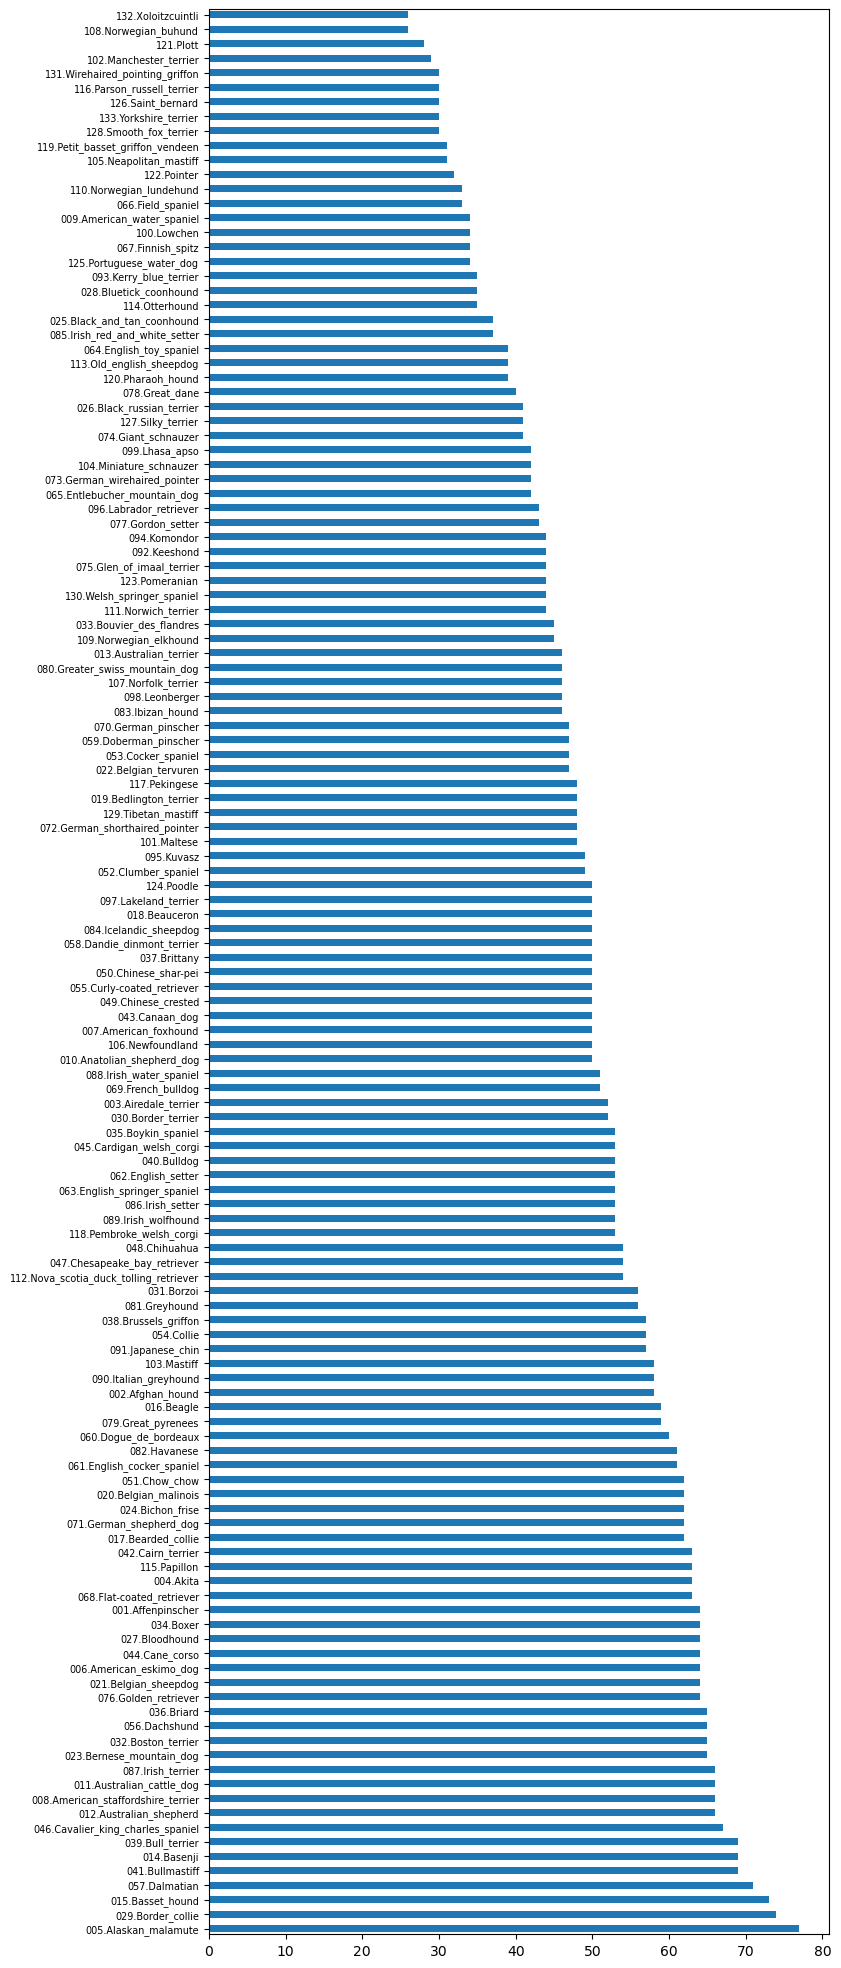

In [9]:
fig, ax = plt.subplots(figsize=(8,25), dpi=100)

hbars = ax.barh(y = train_summary.index, 
               width = train_summary,
               height = .5, )
plt.margins(y=.001)
plt.yticks( fontsize='x-small')

plt.show()

### Sagemaker


In [10]:
import sagemaker

sagemaker_session = sagemaker.Session()

bucket = sagemaker_session.default_bucket()
prefix = "sagemaker/Image_classification"

role = sagemaker.get_execution_role()

print(f"Bucket  : {bucket}")
print(f"Session : {sagemaker_session}")
print(f"role    : {role}")

Bucket  : sagemaker-us-east-1-559647231942
Session : <sagemaker.session.Session object at 0x7f5b3726cd90>
role    : arn:aws:iam::559647231942:role/service-role/AmazonSageMaker-ExecutionRole-20240713T213821


In [11]:
s3_data_location = "s3://sagemaker-us-east-1-559647231942/sagemaker/Image_classification"

In [13]:

s3_data_location = sagemaker_session.upload_data(path="dogImages", bucket=bucket, key_prefix=prefix)
s3_data_location

's3://sagemaker-us-east-1-559647231942/sagemaker/Image_classification'

## Hyperparameter Tuning
**TODO:** This is the part where you will finetune a pretrained model with hyperparameter tuning. Remember that you have to tune a minimum of two hyperparameters. However you are encouraged to tune more. You are also encouraged to explain why you chose to tune those particular hyperparameters and the ranges.

**Note:** You will need to use the `hpo.py` script to perform hyperparameter tuning.

In [12]:
#TODO: Declare your HP ranges, metrics etc.


hyperparameter_ranges = {
    "lr"         : ContinuousParameter(0.001, 0.1),
    "batch-size" : CategoricalParameter([16, 32, 64 ]),
    "epochs"     : IntegerParameter(10,  20)
}


objective_metric_name = "Accuracy"
objective_type = "Maximize"
metric_definitions = [{"Name": "Accuracy", "Regex": "Test set: Accuracy: ([0-9\\.]+)"}]


In [13]:
#TODO: Create estimators for your HPs

# estimator = # TODO: Your estimator here
estimator = PyTorch(
    entry_point="hpo.py",
    role=role,
    py_version       = 'py36', #  'py311'         , #'py36',
    framework_version= "1.8" , #   "2.3"   , #"1.8",
    instance_count=1,
    instance_type= "ml.g4dn.xlarge", #"ml.p2.xlarge", #"ml.g4dn.xlarge"   #ml.m5.large"  #ml.g4dn.2xlarge
)

# tuner = # TODO: Your HP tuner here
tuner = HyperparameterTuner(
    estimator,
    objective_metric_name,
    hyperparameter_ranges,
    metric_definitions,
    max_jobs =6,
    max_parallel_jobs=2,
    objective_type=objective_type,
)

In [14]:
# # pass the number of classes to the hpo.py 
# hyperparameter_ranges['num-classes'] = train_classes


In [15]:
# def setOSenvironment():
#     os.environ['SM_CHANNEL_TRAIN'] = s3_train_location  # s3_data_location + "/train/"
#     os.environ['SM_CHANNEL_VAL']   = s3_val_location    # s3_data_location + "/valid/"
#     os.environ['SM_CHANNEL_TEST']  = s3_test_location   # s3_data_location + "/test/"
#     os.environ['SM_MODEL_DIR']     = s3_data_location + "/model/"
#     # os.environ['NUM_CLASSES']      =  str(train_classes)

In [16]:
# TODO: Fit your HP Tuner
# tuner.fit() # TODO: Remember to include your data channels


s3_train_location = s3_data_location + "/train/"
s3_val_location   = s3_data_location + "/valid/"
s3_test_location  = s3_data_location + "/test/"

os.environ['SM_CHANNEL_TRAIN'] = s3_train_location  # s3_data_location + "/train/"
os.environ['SM_CHANNEL_VAL']   = s3_val_location    # s3_data_location + "/valid/"
os.environ['SM_CHANNEL_TEST']  = s3_test_location   # s3_data_location + "/test/"
os.environ['SM_MODEL_DIR']     = s3_data_location + "/model/"
os.environ['SM_USER_ARGS']     = '["--user-arg", f"{train_classes}"]'



In [17]:

tuner.fit({ 'train': s3_train_location   ,
            'test' : s3_test_location    ,
            'val'  : s3_val_location   
            }, wait=False)

# TODO: Remember to include your data channels

No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config
No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


### Find the completed hyperparameter tuning and find the best estimator 

In [18]:
def findBestHyperParameterTuningJob(get_job_nbr=1):
     
    sagemaker_client = boto3.client('sagemaker')

    response = sagemaker_client.list_hyper_parameter_tuning_jobs(
        MaxResults=1,  # Adjust as needed
        SortBy='Name',
        SortOrder='Descending'
    )

    i = 0
    jobs_list= iter(response['HyperParameterTuningJobSummaries'])

    while (i < get_job_nbr):
        i +=1
        first_item = next(jobs_list)
        print(f"first job name = {first_item['HyperParameterTuningJobName']}")


    tuning_job_name = ( first_item['HyperParameterTuningJobName'])
    print(tuning_job_name)

    tuning_job_details = sagemaker_client.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=tuning_job_name) 


    # https://docs.aws.amazon.com/sagemaker/latest/APIReference/API_DescribeHyperParameterTuningJob.html#sagemaker-DescribeHyperParameterTuningJob-request-HyperParameterTuningJobName
    best_training_job_name = tuning_job_details['BestTrainingJob']['TrainingJobName']
    print(f"Best Training Job Name: {best_training_job_name}")


    best_training_job_details = sagemaker_client.describe_training_job(TrainingJobName=best_training_job_name )
    model_artifacts_s3_path = best_training_job_details['ModelArtifacts']['S3ModelArtifacts']
    print(f"Best Model Artifacts S3 Path: {model_artifacts_s3_path}")

    return best_training_job_name, model_artifacts_s3_path, model_artifacts_s3_path



In [20]:
best_training_job_name, model_artifacts_s3_path, best_estimator = findBestHyperParameterTuningJob(1)


first job name = pytorch-training-250114-1933
pytorch-training-250114-1933
Best Training Job Name: pytorch-training-250114-1933-002-04404eef
Best Model Artifacts S3 Path: s3://sagemaker-us-east-1-559647231942/pytorch-training-250114-1933-002-04404eef/output/model.tar.gz


In [22]:
best_estimator = sagemaker.estimator.Estimator.attach(best_training_job_name)


2025-01-14 20:11:46 Starting - Preparing the instances for training
2025-01-14 20:11:46 Downloading - Downloading the training image
2025-01-14 20:11:46 Training - Training image download completed. Training in progress.
2025-01-14 20:11:46 Uploading - Uploading generated training model
2025-01-14 20:11:46 Completed - Resource reused by training job: pytorch-training-250114-1933-004-10c84005


In [23]:
best_estimator.model_data

's3://sagemaker-us-east-1-559647231942/pytorch-training-250114-1933-002-04404eef/output/model.tar.gz'

In [24]:
print(model_artifacts_s3_path)

s3://sagemaker-us-east-1-559647231942/pytorch-training-250114-1933-002-04404eef/output/model.tar.gz


In [25]:
# TODO: Get the best estimators and the best HPs

# best_estimator = tuner.best_estimator() #TODO

#Get the hyperparameters of the best trained model
best_estimator.hyperparameters()

hyperparameters = { "lr"            :     best_estimator.hyperparameters()['lr'],
                    "batch-size"    :  int(best_estimator.hyperparameters()['batch-size'].replace('"', '')), 
                    "epochs"        :     best_estimator.hyperparameters()['epochs'],
                    "num-classes"   : int(train_classes),
                    "model-data"    : best_estimator.model_data
                   }

hyperparameters

{'lr': '0.003540967141298956',
 'batch-size': 64,
 'epochs': '18',
 'num-classes': 133,
 'model-data': 's3://sagemaker-us-east-1-559647231942/pytorch-training-250114-1933-002-04404eef/output/model.tar.gz'}

In [26]:
best_estimator.hyperparameters()

{'_tuning_objective_metric': 'Accuracy',
 'batch-size': '"64"',
 'epochs': '18',
 'lr': '0.003540967141298956',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"pytorch-training-2025-01-14-19-33-47-722"',
 'sagemaker_program': '"hpo.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-19-33-47-722/source/sourcedir.tar.gz"'}

## Model Profiling and Debugging
TODO: Using the best hyperparameters, create and finetune a new model

**Note:** You will need to use the `train_model.py` script to perform model profiling and debugging.

In [27]:
# TODO: Set up debugging and profiling rules and hooks


# Set up debugging and profiling rules and hooks
rules = [
    Rule.sagemaker(rule_configs.vanishing_gradient()),
    Rule.sagemaker(rule_configs.overfit()),
    Rule.sagemaker(rule_configs.overtraining()),
    Rule.sagemaker(rule_configs.poor_weight_initialization()),
    Rule.sagemaker(rule_configs.loss_not_decreasing()),
    ProfilerRule.sagemaker(rule_configs.LowGPUUtilization()),
    ProfilerRule.sagemaker(rule_configs.ProfilerReport())
]

# create debugger and profiler configurations

collection_configs=[CollectionConfig(name="NLLLoss_output_0", 
                                parameters={"include_regex": "NLLLoss_output_0"}  ) ]


hook_config = DebuggerHookConfig(
    collection_configs=collection_configs,
    hook_parameters={"train.save_interval": "100", 
                     "eval.save_interval" : "10"}
)


profiler_config = ProfilerConfig(
    system_monitor_interval_millis=500, 
    framework_profile_params=FrameworkProfile(num_steps=10)
)


Framework profiling will be deprecated from tensorflow 2.12 and pytorch 2.0 in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


#### Train the model and make use of the best hyperparamter job weights as a starting point

In [28]:
# TODO: Create and fit an estimator

# estimator = # TODO: Your estimator here

# setOSenvironment()

estimator = PyTorch(
    entry_point="train_model.py",
    role=role,
    py_version='py36',
    framework_version="1.8",
    instance_count=1,
    instance_type="ml.g4dn.xlarge",
    hyperparameters=hyperparameters,
    profiler_config=profiler_config,
    rules=rules,
    debugger_hook_config=hook_config
)

estimator.fit({ 'train': s3_train_location   ,
            'test' : s3_test_location    ,
            'val'  : s3_val_location   
            }, wait=False)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2025-01-14-21-25-15-196


In [29]:
# TODO: Plot a debugging output.
from smdebug.trials import create_trial
from smdebug.core.modes import ModeKeys

trial = create_trial(estimator.latest_job_debugger_artifacts_path())

[2025-01-14 22:16:54.154 default:563 INFO s3_trial.py:42] Loading trial debug-output at path s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/debug-output


In [30]:
trial.tensor_names()

[2025-01-14 22:16:59.668 default:563 INFO trial.py:197] Training has ended, will refresh one final time in 1 sec.


[2025-01-14 22:17:00.690 default:563 INFO trial.py:210] Loaded all steps


['NLLLoss_output_0',
 'gradient/ResNet_fc.0.bias',
 'gradient/ResNet_fc.0.weight',
 'layer1.0.relu_input_0',
 'layer1.0.relu_input_1',
 'layer1.0.relu_input_2',
 'layer1.1.relu_input_0',
 'layer1.1.relu_input_1',
 'layer1.1.relu_input_2',
 'layer1.2.relu_input_0',
 'layer1.2.relu_input_1',
 'layer1.2.relu_input_2',
 'layer2.0.relu_input_0',
 'layer2.0.relu_input_1',
 'layer2.0.relu_input_2',
 'layer2.1.relu_input_0',
 'layer2.1.relu_input_1',
 'layer2.1.relu_input_2',
 'layer2.2.relu_input_0',
 'layer2.2.relu_input_1',
 'layer2.2.relu_input_2',
 'layer2.3.relu_input_0',
 'layer2.3.relu_input_1',
 'layer2.3.relu_input_2',
 'layer3.0.relu_input_0',
 'layer3.0.relu_input_1',
 'layer3.0.relu_input_2',
 'layer3.1.relu_input_0',
 'layer3.1.relu_input_1',
 'layer3.1.relu_input_2',
 'layer3.2.relu_input_0',
 'layer3.2.relu_input_1',
 'layer3.2.relu_input_2',
 'layer3.3.relu_input_0',
 'layer3.3.relu_input_1',
 'layer3.3.relu_input_2',
 'layer3.4.relu_input_0',
 'layer3.4.relu_input_1',
 'layer

In [31]:
len(trial.tensor("NLLLoss_output_0").steps(mode=ModeKeys.TRAIN))

20

In [32]:
len(trial.tensor("NLLLoss_output_0").steps(mode=ModeKeys.EVAL))

26

In [33]:
def get_data(trial, tname, mode):
    tensor = trial.tensor(tname)
    steps = tensor.steps(mode=mode)
    vals = []
    for s in steps:
        vals.append(tensor.value(s, mode=mode))
    return steps, vals

In [34]:
from mpl_toolkits.axes_grid1 import host_subplot


def plot_tensor(trial, tensor_name):

    steps_train, vals_train = get_data(trial, tensor_name, mode=ModeKeys.TRAIN)
    print("loaded TRAIN data")
    steps_eval, vals_eval = get_data(trial, tensor_name, mode=ModeKeys.EVAL)
    print("loaded EVAL data")

    fig = plt.figure(figsize=(10, 7))
    host = host_subplot(111)

    par = host.twiny()

    host.set_xlabel("Steps (TRAIN)")
    par.set_xlabel("Steps (EVAL)")
    host.set_ylabel(tensor_name)

    (p1,) = host.plot(steps_train, vals_train, label=tensor_name)
    print("completed TRAIN plot")
    (p2,) = par.plot(steps_eval, vals_eval, label="val_" + tensor_name)
    print("completed EVAL plot")
    leg = plt.legend()

    host.xaxis.get_label().set_color(p1.get_color())
    leg.texts[0].set_color(p1.get_color())

    par.xaxis.get_label().set_color(p2.get_color())
    leg.texts[1].set_color(p2.get_color())

    plt.ylabel(tensor_name)

    plt.show()

loaded TRAIN data
loaded EVAL data
completed TRAIN plot
completed EVAL plot


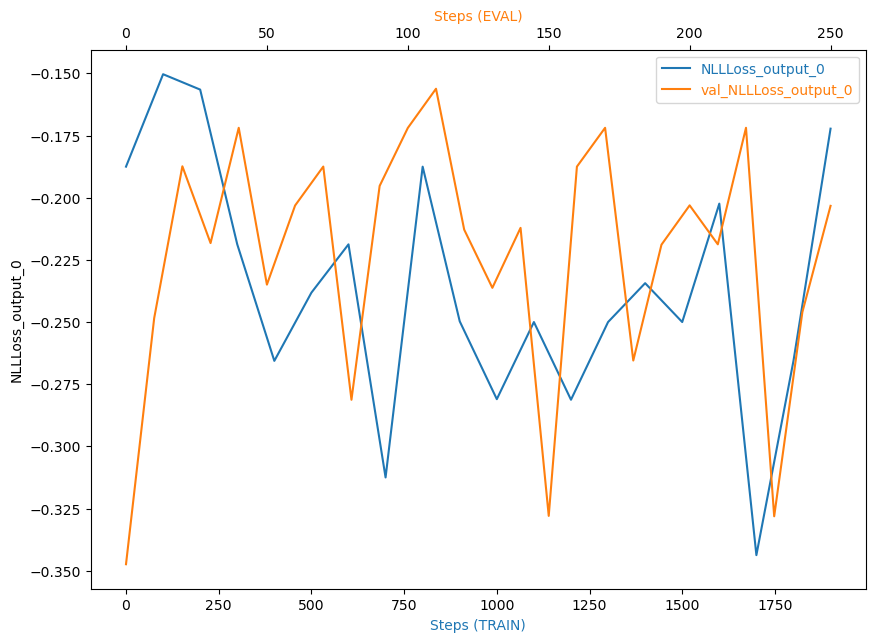

In [35]:
plot_tensor(trial, "NLLLoss_output_0")

**TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
**TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

In [36]:
# TODO: Display the profiler output
rule_output_path = estimator.output_path + estimator.latest_training_job.job_name + "/rule-output"

In [37]:
! aws s3 ls {rule_output_path} --recursive

2025-01-14 22:04:17     415345 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-report.html
2025-01-14 22:04:16     269994 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb
2025-01-14 22:04:11        192 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json
2025-01-14 22:04:11      87202 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json
2025-01-14 22:04:11       1941 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/Dataloader.json
2025-01-14 22:04:11        328 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/GPUMemoryIncrease.json
2025-01-14 22:04:11       2758 pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-re

In [38]:
! aws s3 cp {rule_output_path} ./ --recursive

download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json to ProfilerReport/profiler-output/profiler-reports/BatchSize.json
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb to ProfilerReport/profiler-output/profiler-report.ipynb
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-report.html to ProfilerReport/profiler-output/profiler-report.html
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/rule-output/ProfilerReport/profiler-output/profiler-reports/MaxInitializationTime.json to ProfilerReport/profiler-output/profiler-reports/MaxInitializationTime.json
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/rule-outp

In [66]:
# import os

# get the autogenerated folder name of profiler report
profiler_report_name = [
    rule["RuleConfigurationName"]
    for rule in estimator.latest_training_job.rule_job_summary()
    if "Profiler" in rule["RuleConfigurationName"]
][0]

In [75]:
tmp = profiler_report_name + "/profiler-output/profiler-report.html"

In [76]:
IPython.display.HTML(filename="./" + profiler_report_name + "/profiler-output/profiler-report.html")

## Model Deploying

In [41]:
latest_job = f"s3://{bucket}/{estimator.latest_training_job.job_name}/output/model.tar.gz"
latest_job

's3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/output/model.tar.gz'

In [42]:
estimator.model_data

's3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/output/model.tar.gz'

In [48]:
# TODO: Deploy your model to an endpoint

# TODO: Add your deployment configuration like instance type and number of instances

from sagemaker.pytorch import PyTorchModel
from sagemaker.serializers import IdentitySerializer
from sagemaker.deserializers import JSONDeserializer

pytorch_model = PyTorchModel(model_data=estimator.model_data, 
                             role=role,
                             py_version='py36',
                             framework_version="1.8",
                             entry_point='inferencelocal.py',
                             )
                             


deployment = pytorch_model.deploy(initial_instance_count=1, instance_type='ml.m5.large', serializer=IdentitySerializer("image/jpeg"), deserializer=JSONDeserializer())

endpoint = deployment.endpoint_name

print(endpoint)



INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/output/model.tar.gz), script artifact (None), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-559647231942/pytorch-inference-2025-01-14-22-35-39-630/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-inference-2025-01-14-22-35-48-486
INFO:sagemaker:Creating endpoint-config with name pytorch-inference-2025-01-14-22-35-49-246
INFO:sagemaker:Creating endpoint with name pytorch-inference-2025-01-14-22-35-49-246


-------!pytorch-inference-2025-01-14-22-35-49-246


In [53]:
import io
from PIL import Image

buffer = io.BytesIO()
Image.open("dogImages/test/133.Yorkshire_terrier/Yorkshire_terrier_08325.jpg").save(buffer, format="JPEG")
payload = buffer.getvalue()

inference = deployment.predict(payload)
print(inference)

12


In [55]:
buffer = io.BytesIO()
Image.open("dogImages/test/005.Alaskan_malamute/Alaskan_malamute_00330.jpg").save(buffer, format="JPEG")
image = buffer.getvalue()

inference = deployment.predict(payload)
print(inference)

12


## Batch Inferencing

In [56]:

# Create a SageMaker client
sagemaker_client = boto3.client('sagemaker')

# List training jobs
response = sagemaker_client.list_training_jobs(
    SortBy='CreationTime', 
    SortOrder='Descending',
    MaxResults=1
    )

# Get the latest training job
latest_training_job = response['TrainingJobSummaries'][0]  # The first one is the latest
print("Latest Training Job:")
print(f"Name: {latest_training_job['TrainingJobName']}")
print(f"Status: {latest_training_job['TrainingJobStatus']}")
print(f"Creation Time: {latest_training_job['CreationTime']}")



my_estimator = sagemaker.estimator.Estimator.attach(latest_training_job['TrainingJobName'])

my_estimator.hyperparameters()
best_estimator=my_estimator


Latest Training Job:
Name: pytorch-training-2025-01-14-21-25-15-196
Status: Completed
Creation Time: 2025-01-14 21:25:16.551000+00:00

2025-01-14 22:05:47 Starting - Preparing the instances for training
2025-01-14 22:05:47 Downloading - Downloading the training image
2025-01-14 22:05:47 Training - Training image download completed. Training in progress.
2025-01-14 22:05:47 Uploading - Uploading generated training model
2025-01-14 22:05:47 Completed - Training job completed


In [57]:
%%capture
!pip install jsonlines 

In [58]:
import jsonlines
from os import listdir
from os.path import isfile, join

# Build image list
s3_bucket = "sagemaker-us-east-1-559647231942"
manifest_prefix = f"s3://{s3_bucket}/images/"  # test images were copied earlier in the s3 buckets

image_dir = "images"

path = image_dir
img_files = [f for f in listdir(path) if isfile(join(path, f))]

print("img_files\n", img_files)

manifest_content = [{"prefix": manifest_prefix}]
manifest_content.extend(img_files)

print("manifest_content\n", manifest_content)

# Write jsonl file
manifest_file = "manifest.json"
with jsonlines.open(manifest_file, mode="w") as writer:
    writer.write(manifest_content)

# Upload to S3
manifest_obj = sagemaker_session.upload_data(path=manifest_file )

print("manifest_obj\n", manifest_obj)

img_files
 ['Afghan_hound_00100.jpg', 'American_foxhound_00526.jpg', 'American_foxhound_00487.jpg', 'Afghan_hound_00115.jpg', 'Afghan_hound_00106.jpg', 'Afghan_hound_00132.jpg', 'Afghan_hound_00120.jpg', 'American_foxhound_00505.jpg', 'American_foxhound_00523.jpg', 'Australian_terrier_00893.jpg', 'Afghan_hound_00129.jpg', 'Afghan_hound_00095.jpg', 'Australian_terrier_00913.jpg', 'Australian_terrier_00927.jpg', 'American_foxhound_00485.jpg', 'Australian_terrier_00896.jpg', 'Australian_terrier_00914.jpg', 'Australian_terrier_00929.jpg']
manifest_content
 [{'prefix': 's3://sagemaker-us-east-1-559647231942/images/'}, 'Afghan_hound_00100.jpg', 'American_foxhound_00526.jpg', 'American_foxhound_00487.jpg', 'Afghan_hound_00115.jpg', 'Afghan_hound_00106.jpg', 'Afghan_hound_00132.jpg', 'Afghan_hound_00120.jpg', 'American_foxhound_00505.jpg', 'American_foxhound_00523.jpg', 'Australian_terrier_00893.jpg', 'Afghan_hound_00129.jpg', 'Afghan_hound_00095.jpg', 'Australian_terrier_00913.jpg', 'Australi

In [59]:
# Batch transform with manifest file
# Create transformer from PyTorchModel object
transformer = pytorch_model.transformer(instance_count=1, instance_type="ml.c5.xlarge")

transform_job = transformer.transform(
    data = manifest_obj,
    data_type="ManifestFile",
    content_type="image/jpeg",
    wait=False,
)

INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-559647231942/pytorch-training-2025-01-14-21-25-15-196/output/model.tar.gz), script artifact (None), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-559647231942/pytorch-inference-2025-01-14-22-35-48-486/model.tar.gz. This may take some time depending on model size...


INFO:sagemaker:Creating model with name: pytorch-inference-2025-01-14-22-45-42-023
INFO:sagemaker:Creating transform job with name: pytorch-inference-2025-01-14-22-45-42-942


In [62]:
# TODO: Remember to shutdown/delete your endpoint once your work is done
deployment.delete_endpoint()

INFO:sagemaker:Deleting endpoint configuration with name: pytorch-inference-2025-01-14-22-35-49-246
INFO:sagemaker:Deleting endpoint with name: pytorch-inference-2025-01-14-22-35-49-246
